## 04.5: Working With Vector Data Using `Geopandas`

In this notebook, we illustrate how to carry out some basic operations on geospatial data that is in the form of vector data. Vector data differs significantly from raster data, which is the format of geospatial data we've been working with so far. The easiest way to conceptualize vector data is as a table of data containing columns representing variables or fields, and rows that represent geographic records or "features." Importantly, those each geographic records or features can consist of only one fundamental data type – points, lines (or segments), or polygons. In GIS platforms like ArcGIS or QGIS, this table is what's known as the "attribute table" that you can open when you right click on a shapefile/layer/coverage in the data explorer window. Each of the geographic records is associated with information that defines the location of that record in space. For example, point records will be associated (or "related") with their x- and y-coordinates in the coordinate reference system of the dataset. Line records or segments will be associated with two vertices that have associated x- and y- coordinates, as well as the length or distance between those vertices. Finally, a polygon record will be associated with the vertices and lines that enclose the polygon, as well as the area encompassed by those line segments. Line segments of polygons are also a bit more complicated in that they also contain information about which side of the line segment the polygon is located as you would "navigate" from one vertext to the next in a defined direction along the exterior of the polygon. Most commonly, the line segments are navigated such that the polygon is always to the *_right_* of a line segment when moving clockwise from one line segment to the next. 

With this in mind, it becomes clear why we call GIS data a "relational database." The database (table of data) has records (rows) that relate to some geographic feature (a point, line, or polygon). We have already seen taht the `pandas` library is very powerful for dealing with tabular data (in our case in the form of time series, where every record consisted of one interval/point in time). The `geopandas` library is simply an extension of the `pandas` framework that then associates each record in a data table with some geographic feature. While not a powerful and comprehensive GIS platform, it does allow us some pretty helpful utilities for creating, editing, reading, and performing some basic geospatial operations – like reprojection, clipping, and buffering – in Python; without the computational overhead of a full GIS GUI. In the notebook below, we carry out a common workflow that a hydrologist might need to do. Specifically, we will use an existing watershed boundary dataset (a polygon dataset) to clip another dataset that contains the delineated river network (a line dataset) over a broader region. 

## 1. Imports and Definitions

In [1]:
import os
import pandas as pd
import numpy as np
import geopandas as gpd
import folium
import matplotlib.pyplot as plt

nhd_file = '../data/NHD_H_1705_HU4_GPKG.gpkg' # Middle Snake (inc. Boise)
ws_file = '../data/ubrb/upper_boise_geometry.shp'

export_file = '../data/ubrb_hydrography.geojson'

epsg_utm = 32613

In [2]:
ws_gdf = gpd.read_file(ws_file)
ws_gdf

,sourcedata,areaacres,sourcefeat,shape_leng,states,sourceorig,shape_area,huc8,areasqkm,name,tnmid,metasource,loaddate,gnis_id,geometry
0,None,486280.99,None,2.82926983182592,ID,None,0.220329659705026,17050111,1967.91,North and Middle Forks Boise,{61B79CD3-38D5-441B-96FB-159A5D2D00B7},None,20130118135515,None,"POLYGON ((-115.73961 43.74613, -115.7396 43.74..."
1,None,836097.52,None,4.3664242877153,ID,None,0.376885299722635,17050113,3383.57,South Fork Boise,{CFE636CD-99A5-4D5C-B08A-6CA824951654},None,20130118135515,None,"POLYGON ((-115.93718 43.51423, -115.93718 43.5..."
2,None,397423.64,None,2.78095370323452,ID,None,0.1797845336911,17050112,1608.32,Boise-Mores,{C3D4B475-E628-4FA4-9287-17E51741B72E},None,20130118135515,None,"POLYGON ((-116.10022 43.69616, -116.10022 43.6..."


In [3]:
ws_gdf.explore()

In [4]:
gpd.list_layers(nhd_file)

/Users/lejoflores/GEOS-505-Fall2025/env/lib/python3.12/site-packages/pyogrio/core.py:130: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D MultiLineString' is converted to 'MultiLineString Z'
  return ogr_list_layers(get_vsi_path_or_buffer(path_or_buffer))


,name,geometry_type
0,NHDArea,MultiPolygon Z
1,NHDAreaEventFC,MultiPolygon
2,NHDFlowline,MultiLineString Z
3,NHDLine,MultiLineString Z
4,NHDLineEventFC,MultiLineString
5,NHDPoint,Point Z
6,NHDPointEventFC,Point
7,NHDWaterbody,MultiPolygon Z
8,WBDHU10,MultiPolygon
9,WBDHU12,MultiPolygon


In [5]:
nhd_gdf = gpd.read_file(nhd_file, layer='NHDFlowline')
nhd_gdf

/Users/lejoflores/GEOS-505-Fall2025/env/lib/python3.12/site-packages/pyogrio/raw.py:198: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D MultiLineString' is converted to 'MultiLineString Z'
  return ogr_read(


,permanent_identifier,fdate,resolution,gnis_id,gnis_name,lengthkm,reachcode,flowdir,wbarea_permanent_identifier,ftype,...,visibilityfilter,SHAPE_Length,Enabled,resolution_description,flowdir_description,mainpath_description,innetwork_description,visibilityfilter_description,fcode_description,geometry
0,131371650,2012-02-21 21:58:09+00:00,2,01128885,West Little Owyhee River,0.631,17050107000199,1,None,460,...,5000000,0.006329,1,High,WithDigitized,Unspecified,Yes,"Approximately 1:5,000,000 or Larger Scale",Stream/River: Hydrographic Category = Perennial,"MULTILINESTRING Z ((-117.33679 42.11858 0, -11..."
1,131371481,2012-02-21 21:59:28+00:00,2,01128885,West Little Owyhee River,0.922,17050107000171,1,None,460,...,5000000,0.009306,1,High,WithDigitized,Unspecified,Yes,"Approximately 1:5,000,000 or Larger Scale",Stream/River: Hydrographic Category = Perennial,"MULTILINESTRING Z ((-117.22919 42.37559 0, -11..."
2,131362970,2012-02-21 22:00:14+00:00,2,None,None,3.085,17050107001900,1,None,460,...,100000,0.034796,1,High,WithDigitized,Unspecified,Yes,"Approximately 1:100,000 or Larger Scale",Stream/River: Hydrographic Category = Intermit...,"MULTILINESTRING Z ((-117.34937 42.47935 0, -11..."
3,131369519,2012-02-21 22:00:14+00:00,2,01125528,Pole Creek,0.328,17050107004176,1,None,460,...,100000,0.003850,1,High,WithDigitized,Unspecified,Yes,"Approximately 1:100,000 or Larger Scale",Stream/River: Hydrographic Category = Intermit...,"MULTILINESTRING Z ((-117.39968 42.14511 0, -11..."
4,131368883,2012-02-21 22:00:14+00:00,2,None,None,1.857,17050107003953,1,None,460,...,50000,0.020510,1,High,WithDigitized,Unspecified,Yes,"Approximately 1:50,000 or Larger Scale",Stream/River: Hydrographic Category = Intermit...,"MULTILINESTRING Z ((-117.3893 42.17981 0, -117..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178761,131362913,2012-02-21 22:00:14+00:00,2,None,None,0.719,17050107001881,1,None,460,...,50000,0.007042,1,High,WithDigitized,Unspecified,Yes,"Approximately 1:50,000 or Larger Scale",Stream/River: Hydrographic Category = Intermit...,"MULTILINESTRING Z ((-117.22941 42.58782 0, -11..."
178762,131361243,2012-02-21 21:57:33+00:00,2,01125528,Pole Creek,1.796,17050107001365,1,None,460,...,500000,0.019701,1,High,WithDigitized,Unspecified,Yes,"Approximately 1:500,000 or Larger Scale",Stream/River: Hydrographic Category = Intermit...,"MULTILINESTRING Z ((-117.36951 42.16781 0, -11..."
178763,165179119,2012-02-21 22:00:14+00:00,2,None,None,1.047,17050107002297,1,None,460,...,50000,0.010254,1,High,WithDigitized,Unspecified,Yes,"Approximately 1:50,000 or Larger Scale",Stream/River: Hydrographic Category = Intermit...,"MULTILINESTRING Z ((-117.10803 42.59166 0, -11..."
178764,165179122,2012-02-21 21:58:44+00:00,2,None,None,1.275,17050107000917,1,None,460,...,100000,0.015242,1,High,WithDigitized,Unspecified,Yes,"Approximately 1:100,000 or Larger Scale",Stream/River: Hydrographic Category = Intermit...,"MULTILINESTRING Z ((-117.10392 42.58347 0, -11..."


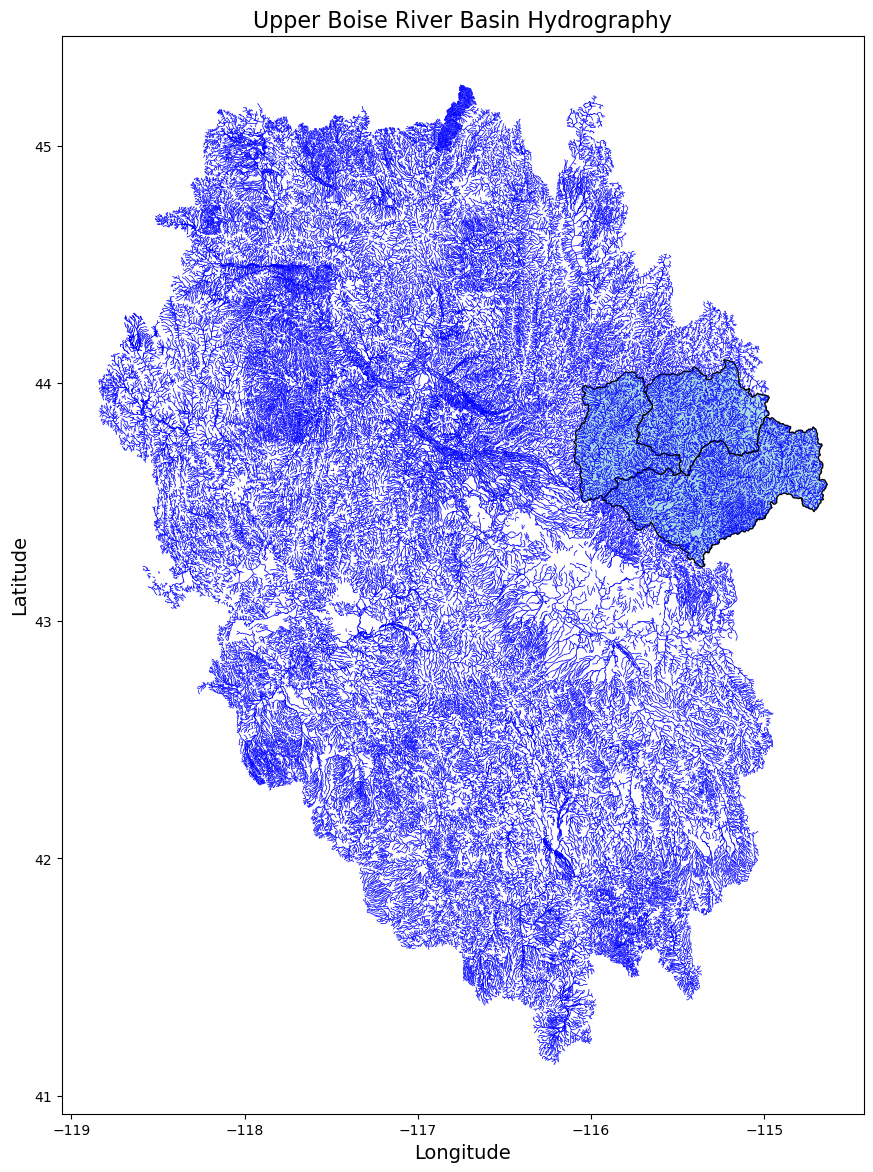

In [6]:
fig, ax = plt.subplots(figsize=(14,14))
ws_gdf.plot(color='lightblue', edgecolor='black', ax=ax)
nhd_gdf.plot(color='blue', linewidth=0.5, ax=ax)
ax.set_title('Upper Boise River Basin Hydrography', fontsize=16)
ax.set_xlabel('Longitude', fontsize=14)
ax.set_ylabel('Latitude', fontsize=14)
plt.show()

In [7]:
ws_gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [8]:
nhd_gdf.crs

<Geographic 2D CRS: EPSG:4269>
Name: NAD83
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: North America - onshore and offshore: Canada - Alberta; British Columbia; Manitoba; New Brunswick; Newfoundland and Labrador; Northwest Territories; Nova Scotia; Nunavut; Ontario; Prince Edward Island; Quebec; Saskatchewan; Yukon. Puerto Rico. United States (USA) - Alabama; Alaska; Arizona; Arkansas; California; Colorado; Connecticut; Delaware; Florida; Georgia; Hawaii; Idaho; Illinois; Indiana; Iowa; Kansas; Kentucky; Louisiana; Maine; Maryland; Massachusetts; Michigan; Minnesota; Mississippi; Missouri; Montana; Nebraska; Nevada; New Hampshire; New Jersey; New Mexico; New York; North Carolina; North Dakota; Ohio; Oklahoma; Oregon; Pennsylvania; Rhode Island; South Carolina; South Dakota; Tennessee; Texas; Utah; Vermont; Virginia; Washington; West Virginia; Wisconsin; Wyoming. US Virgin Islands. British Virgin Islands

In [9]:
ws_utm_gdf = ws_gdf.to_crs(epsg=epsg_utm)
ws_utm_gdf.crs

<Projected CRS: EPSG:32613>
Name: WGS 84 / UTM zone 13N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 108°W and 102°W, northern hemisphere between equator and 84°N, onshore and offshore. Canada - Northwest Territories (NWT); Nunavut; Saskatchewan. Mexico. United States (USA).
- bounds: (-108.0, 0.0, -102.0, 84.0)
Coordinate Operation:
- name: UTM zone 13N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [10]:
nhd_utm_gdf = nhd_gdf.to_crs(epsg=epsg_utm)
nhd_utm_gdf.crs

<Projected CRS: EPSG:32613>
Name: WGS 84 / UTM zone 13N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 108°W and 102°W, northern hemisphere between equator and 84°N, onshore and offshore. Canada - Northwest Territories (NWT); Nunavut; Saskatchewan. Mexico. United States (USA).
- bounds: (-108.0, 0.0, -102.0, 84.0)
Coordinate Operation:
- name: UTM zone 13N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [11]:
nhd_clipped_gdf = gpd.clip(nhd_utm_gdf, ws_utm_gdf)
nhd_clipped_gdf

,permanent_identifier,fdate,resolution,gnis_id,gnis_name,lengthkm,reachcode,flowdir,wbarea_permanent_identifier,ftype,...,visibilityfilter,SHAPE_Length,Enabled,resolution_description,flowdir_description,mainpath_description,innetwork_description,visibilityfilter_description,fcode_description,geometry
3288,55020871,2012-01-21 22:05:01+00:00,2,None,None,0.494,17050113350593,1,None,460,...,24000,0.005588,1,High,WithDigitized,Unspecified,Yes,"Approximately 1:24,000 or Larger Scale",Stream/River: Hydrographic Category = Intermit...,"LINESTRING Z (-319251.587 4852496.485 0, -3192..."
41658,55020843,2012-01-21 22:05:01+00:00,2,None,None,0.932,17050113350585,1,None,460,...,24000,0.009987,1,High,WithDigitized,Unspecified,Yes,"Approximately 1:24,000 or Larger Scale",Stream/River: Hydrographic Category = Intermit...,"LINESTRING Z (-318948.857 4853095.927 0, -3189..."
11952,55020817,2012-01-21 22:05:00+00:00,2,None,None,1.565,17050113001296,1,None,460,...,24000,0.018053,1,High,WithDigitized,Unspecified,Yes,"Approximately 1:24,000 or Larger Scale",Stream/River: Hydrographic Category = Intermit...,"LINESTRING Z (-317565.743 4852976.235 0, -3175..."
50663,55020749,2012-01-21 22:05:00+00:00,2,None,None,0.699,17050113350562,1,None,460,...,24000,0.007269,1,High,WithDigitized,Unspecified,Yes,"Approximately 1:24,000 or Larger Scale",Stream/River: Hydrographic Category = Intermit...,"LINESTRING Z (-317198.555 4853353.002 0, -3172..."
33181,55020693,2012-01-21 22:04:59+00:00,2,None,None,0.371,17050113350549,1,None,460,...,100000,0.003472,1,High,WithDigitized,Unspecified,Yes,"Approximately 1:100,000 or Larger Scale",Stream/River: Hydrographic Category = Intermit...,"LINESTRING Z (-319668.456 4853433.734 0, -3196..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149525,52470630,2012-01-21 21:30:12+00:00,2,None,None,1.531,17050112000186,1,None,460,...,24000,0.014394,1,High,WithDigitized,Unspecified,Yes,"Approximately 1:24,000 or Larger Scale",Stream/River: Hydrographic Category = Perennial,"LINESTRING Z (-364826.188 4932152.293 0, -3648..."
2855,52470615,2012-01-21 21:30:12+00:00,2,None,None,1.332,17050112098606,1,None,460,...,24000,0.013832,1,High,WithDigitized,Unspecified,Yes,"Approximately 1:24,000 or Larger Scale",Stream/River: Hydrographic Category = Intermit...,"LINESTRING Z (-365404.043 4932408.74 0, -36541..."
168841,52470583,2012-01-21 21:30:12+00:00,2,00399902,Grimes Creek,0.690,17050112000144,1,None,460,...,5000000,0.007325,1,High,WithDigitized,Unspecified,Yes,"Approximately 1:5,000,000 or Larger Scale",Stream/River: Hydrographic Category = Perennial,"LINESTRING Z (-366041.46 4933506.094 0, -36608..."
6394,52470591,2012-01-21 21:30:12+00:00,2,00399902,Grimes Creek,0.742,17050112000145,1,None,460,...,2000000,0.008751,1,High,WithDigitized,Unspecified,Yes,"Approximately 1:2,000,000 or Larger Scale",Stream/River: Hydrographic Category = Perennial,"LINESTRING Z (-363858.075 4933179.641 0, -3638..."


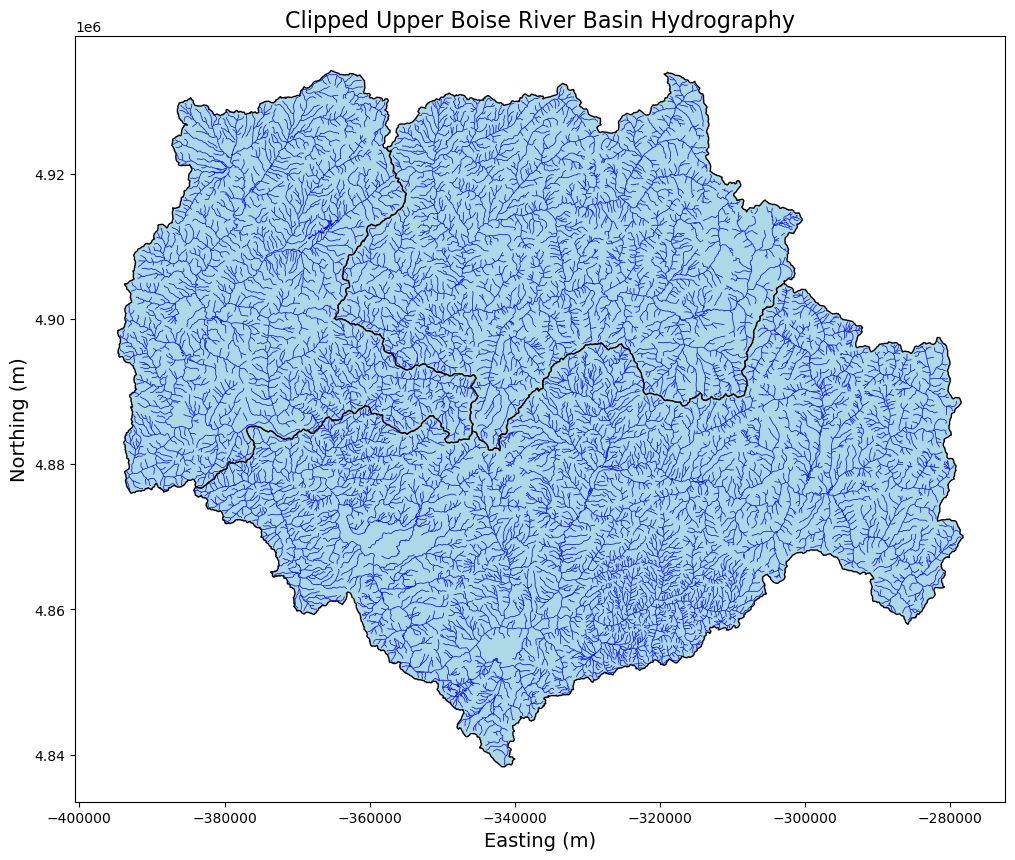

In [12]:
fig, ax = plt.subplots(figsize=(12,12))
ws_utm_gdf.plot(color='lightblue', edgecolor='black', ax=ax)
nhd_clipped_gdf.plot(color='blue', linewidth=0.5, ax=ax)
ax.set_title('Clipped Upper Boise River Basin Hydrography', fontsize=16)
ax.set_xlabel('Easting (m)', fontsize=14)
ax.set_ylabel('Northing (m)', fontsize=14)
plt.show()

In [13]:
if os.path.exists(export_file):
        os.remove(export_file) # Delete the existing file

nhd_clipped_gdf.to_file(export_file, driver='geoJSON')